In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import pickle
import sys
import os
import yaml

from pathlib import Path

sys.path.insert(0, str(Path("..").resolve() / "eitprocessing"))
from eitprocessing.features.rate_detection import RateDetection
from eitprocessing.plotting.rate_detection import RateDetectionPlotting

sys.path.append(r"../src")
from preprocessing import butter_lowpass_filter
from loading import (
    load_synchronized_sequence,
    load_synchronized_pes,
    load_synchronized_eit,
    get_window_mask,
    crop_eit_to_window,
)

sys.path.append(r"../filter")
from SSA_HR import process_pes, rc_pair_overview_dataframe

sys.path.append(r"../config")
from dataset_config import get_dataset_window

sys.path.append(r"../visualization")
from ssa_plots import plot_ssa_overview, plot_cgo_analysis, plot_pes_segment

→ Ruw tijdsvenster PES: 59951.50s–61823.48s


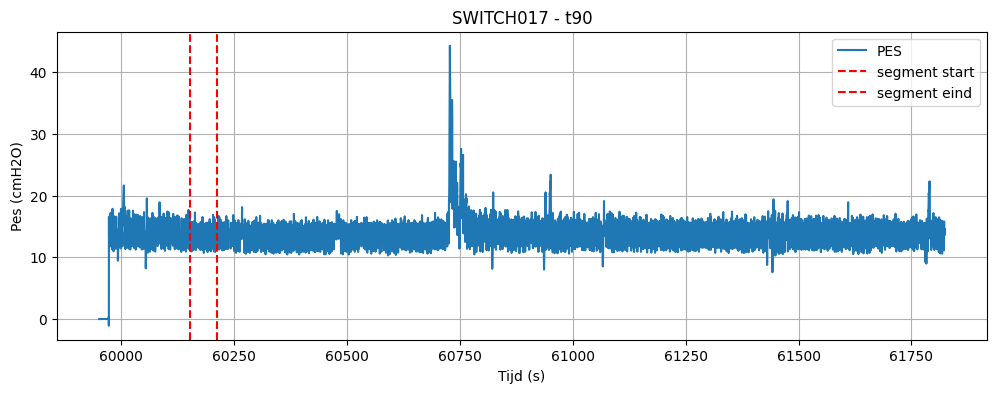

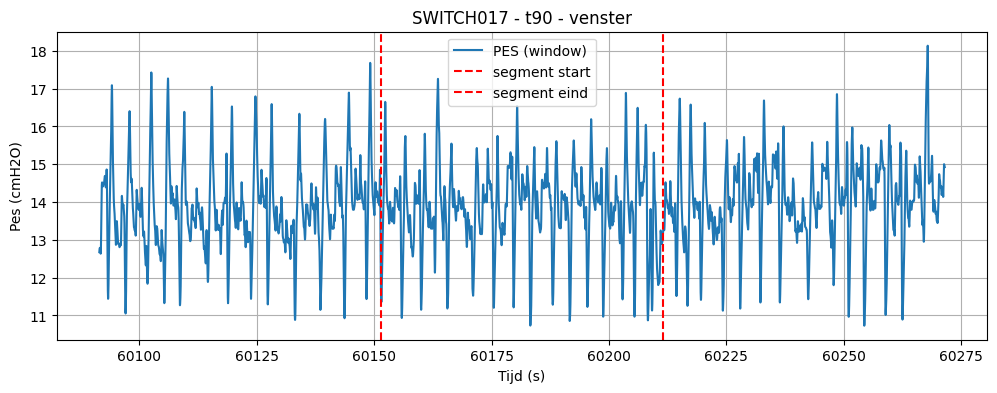

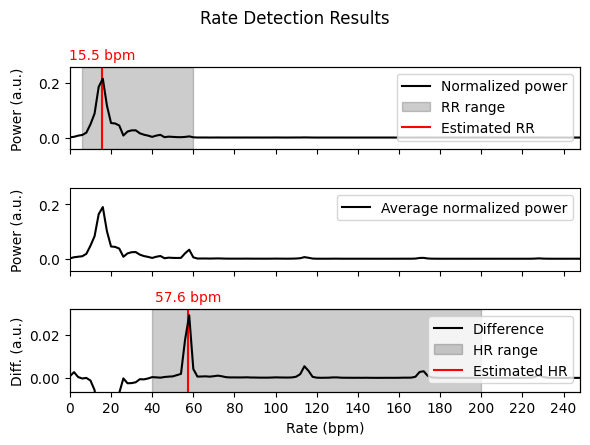

→ Patient: SWITCH017
→ Phase: t90
→ Tijdvenster PES: 60151.50s–60211.50s
→ Tijdvenster EIT: 60151.50s–60211.50s
→ RR (EIT): 15.47 bpm
→ HR (EIT): 57.62 bpm


In [4]:
# ----------------
# Instellingen
# ----------------
patient = "017"   # 002, 004, 005, 006, 009, 010, 011, 012, 014, 015, 016, 017, 018
phase = "t90"     # preswitch, t0, t30, t60, t90, t120, t150, t180, t210
fs = 256
plot_margin = 60

sync_path = rf"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\data\test\SWITCH{patient}_{phase}_sync"


# ---------------------------------------
# Gesynchroniseerde data inladen
# ---------------------------------------
sequence = load_synchronized_sequence(sync_path)

time, pes = load_synchronized_pes(sequence)
eit_signal, eit_time = load_synchronized_eit(sequence)

print(f"→ Ruw tijdsvenster PES: {time[0]:.2f}s–{time[-1]:.2f}s")


# ------------------
# Tijdvenster bepalen
# ------------------
t_start, t_end = get_dataset_window(patient, phase)

# Dataset-window relatief maken aan starttijd van PES
t_start += time[0]
t_end += time[0]


# ------------------
# PES preprocessing
# ------------------
pes_filt = butter_lowpass_filter(pes, cutoff=5, fs=fs)

# ---------------
# PES vensters
# ---------------
pes_segment_mask = get_window_mask(time, t_start, t_end)
pes_plot_mask = get_window_mask(time, t_start - plot_margin, t_end + plot_margin)

time_window = time[pes_segment_mask]
pes_window = pes_filt[pes_segment_mask]

time_pes_plot = time[pes_plot_mask]
pes_plot = pes_filt[pes_plot_mask]


# ------------
# PES plotten
# ------------
plot_pes_segment(
    time=time,
    pes_filt=pes_filt,
    time_pes_plot=time_pes_plot,
    pes_plot=pes_plot,
    t_start=t_start,
    t_end=t_end,
    patient=patient,
    phase=phase,
)


# ---------------
# EIT venster
# ---------------
eit_window, start_idx, end_idx = crop_eit_to_window(
    eit_signal=eit_signal,
    t_start=t_start,
    t_end=t_end,
)


# -------------------
# HR en RR detectie
# -------------------
rd = RateDetection(subject_type="adult")
captures = {}

rr_eit, hr_eit = rd.apply(eit_window, captures=captures)

plotter = RateDetectionPlotting(rd)
fig = plotter.plot(**captures)
plt.show()


# --------
# Output
# --------
print(f"→ Patient: SWITCH{patient}")
print(f"→ Phase: {phase}")
print(f"→ Tijdvenster PES: {time_window[0]:.2f}s–{time_window[-1]:.2f}s")
print(f"→ Tijdvenster EIT: {eit_time[start_idx]:.2f}s–{eit_time[end_idx - 1]:.2f}s")
print(f"→ RR (EIT): {rr_eit * 60:.2f} bpm")
print(f"→ HR (EIT): {hr_eit * 60:.2f} bpm")

→ Ruw tijdsvenster PES: 59951.50s–61823.48s


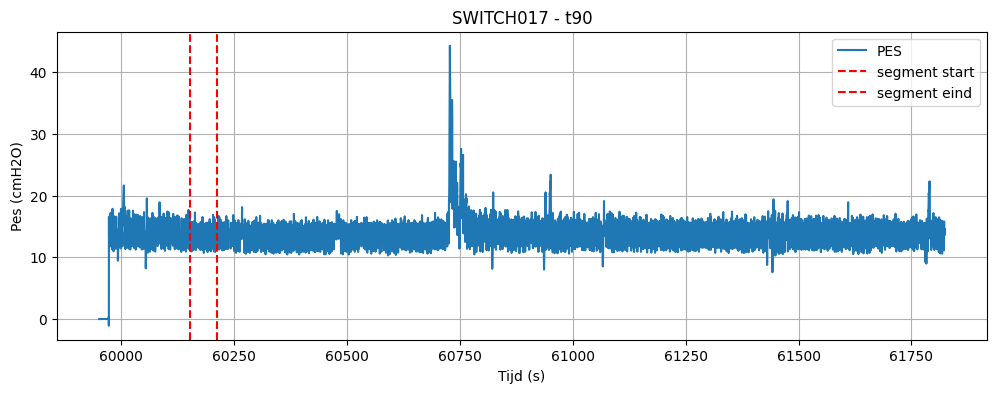

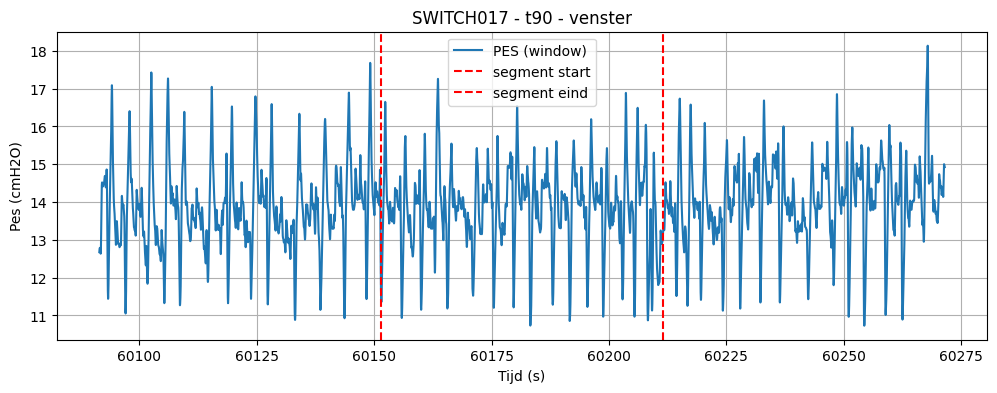

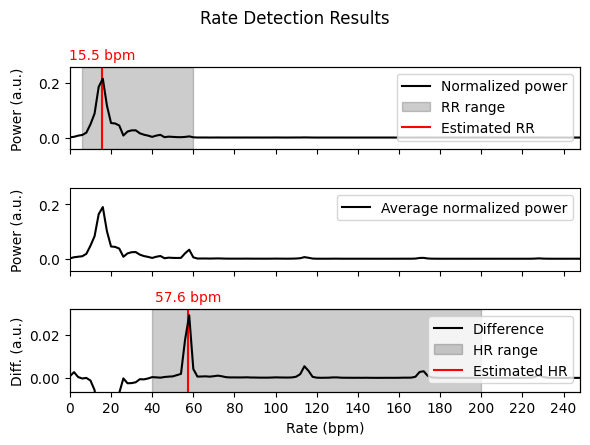

→ Patient: SWITCH017
→ Phase: t90
→ Tijdvenster PES: 60151.50s–60211.50s
→ Tijdvenster EIT: 60151.50s–60211.50s
→ RR (EIT): 15.47 bpm
→ HR (EIT): 57.62 bpm


In [3]:
# ----------------
# Instellingen
# ----------------
patient = "017"   # 002, 004, 005, 006, 009, 010, 011, 012, 014, 015, 016, 017, 018
phase = "t90"    # preswitch, t0, t30, t60, t90, t120, t150, t180, t210
fs = 256
plot_margin = 60  

sync_path = rf"C:\Users\Kaspe\OneDrive\Documenten\TM2\Code\data\test\SWITCH{patient}_{phase}_sync"    #eigen pad naar gesynchronizeerde files


# ---------------------------------------
# Gesynchroniseerde data inladen windows
# ---------------------------------------
class PosixPathFixUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "pathlib" and name == "PosixPath":
            return pathlib.PurePosixPath
        return super().find_class(module, name)

with open(sync_path, "rb") as f:
    sequence = PosixPathFixUnpickler(f).load()


# -------------
# Pes inladen
# -------------
pes_signal = sequence.continuous_data["synchronized_pes"]
time = pes_signal.time
pes = pes_signal.values

print(f"→ Ruw tijdsvenster PES: {time[0]:.2f}s–{time[-1]:.2f}s")

t_start, t_end = get_dataset_window(patient, phase)
t_start += time[0]
t_end += time[0]


# ------------------
# Preprocessing
# ------------------
pes_filt = butter_lowpass_filter(pes, cutoff=5, fs=fs)


# ---------------
# Pes vensters
# ---------------
pes_segment_mask = (time >= t_start) & (time <= t_end)
pes_plot_mask = (time >= t_start - plot_margin) & (time <= t_end + plot_margin)

time_window= time[pes_segment_mask]
pes_window = pes_filt[pes_segment_mask]

time_pes_plot = time[pes_plot_mask]
pes_plot = pes_filt[pes_plot_mask]

plot_pes_segment(
    time=time,
    pes_filt=pes_filt,
    time_pes_plot=time_pes_plot,
    pes_plot=pes_plot,
    t_start=t_start,
    t_end=t_end,
    patient=patient,
    phase=phase,
)

# ------------
# EIT inladen
# ------------
eit_signal = sequence.eit_data["raw"]
eit_time = eit_signal.time

eit_mask = (eit_time >= t_start) & (eit_time <= t_end)
idx = np.where(eit_mask)[0]

start_idx = idx[0]
end_idx = idx[-1] + 1
eit_window = eit_signal[start_idx:end_idx]


# -------------------
# HR en RR detectie
# -------------------
rd = RateDetection(subject_type="adult")
captures = {}

rr_eit, hr_eit = rd.apply(eit_window, captures=captures)

plotter = RateDetectionPlotting(rd)
fig = plotter.plot(**captures)
plt.show()


# --------
# Output
# --------
print(f"→ Patient: SWITCH{patient}")
print(f"→ Phase: {phase}")
print(f"→ Tijdvenster PES: {time_window[0]:.2f}s–{time_window[-1]:.2f}s")
print(f"→ Tijdvenster EIT: {eit_time[start_idx]:.2f}s–{eit_time[end_idx-1]:.2f}s")
print(f"→ RR (EIT): {rr_eit * 60:.2f} bpm")
print(f"→ HR (EIT): {hr_eit * 60:.2f} bpm")

## Singular Spectrum Analysis

In [3]:
pes_bp, cgo, RCs, rc_pairs, chosen_pair, t_hr, hr, peaks, s, pair_scores, cgo_energy, pes_bp_energy, cgo_to_pesbp_ratio = process_pes(time_window, pes_window, fs)

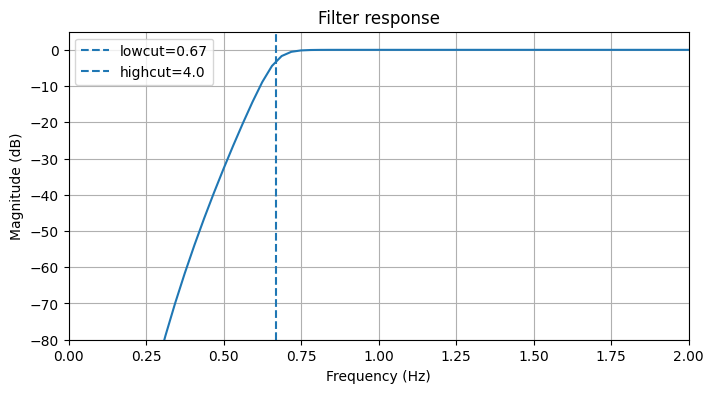

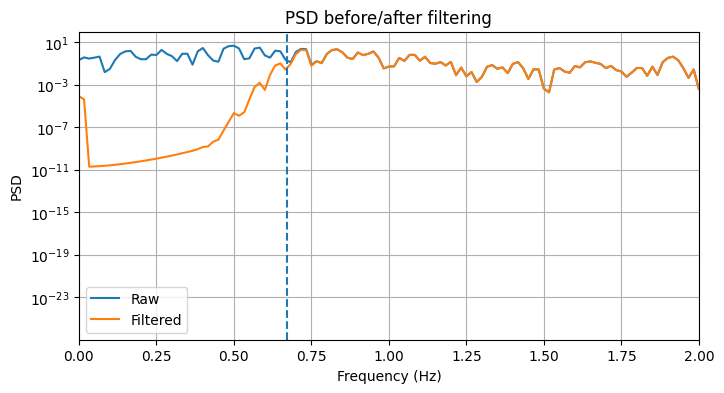

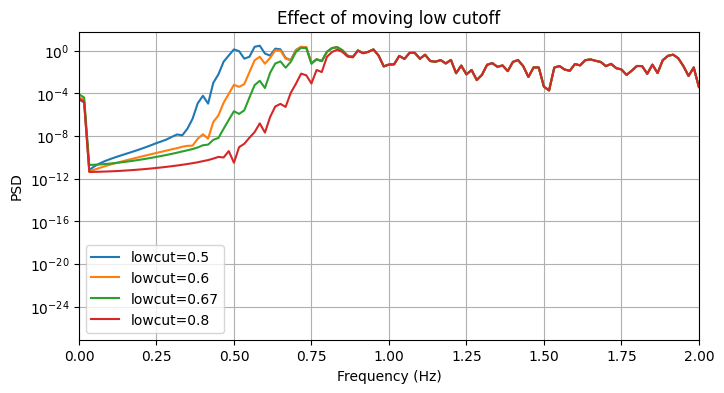

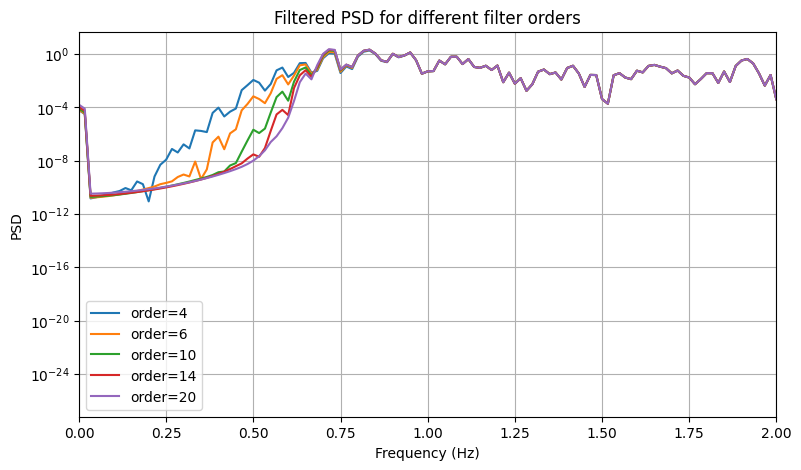

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, sosfreqz, welch

def design_bandpass(fs, lowcut, highcut, order=10):
    nyq = 0.5 * fs
    return butter(order, [lowcut / nyq, highcut / nyq], btype="band", output="sos")

def butter_bandpass_filter(signal, fs, lowcut, highcut, order=10):
    sos = design_bandpass(fs, lowcut, highcut, order)
    return sosfiltfilt(sos, signal)

def plot_filter_response(fs, lowcut, highcut, order=10):
    sos = design_bandpass(fs, lowcut, highcut, order)
    w, h = sosfreqz(sos, worN=4096, fs=fs)

    plt.figure(figsize=(8, 4))
    plt.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)))
    plt.axvline(lowcut, linestyle='--', label=f'lowcut={lowcut}')
    plt.axvline(highcut, linestyle='--', label=f'highcut={highcut}')
    plt.xlim(0, 2)
    plt.ylim(-80, 5)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title("Filter response")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_psd_comparison(signal, fs, lowcut, highcut, order=10):
    filtered = butter_bandpass_filter(signal, fs, lowcut, highcut, order)

    f_raw, P_raw = welch(signal, fs=fs, nperseg = min(len(signal), 16384))
    f_filt, P_filt = welch(filtered, fs=fs, nperseg = min(len(signal), 16384))

    plt.figure(figsize=(8, 4))
    plt.semilogy(f_raw, P_raw, label="Raw")
    plt.semilogy(f_filt, P_filt, label="Filtered")
    plt.axvline(lowcut, linestyle='--')
    plt.axvline(highcut, linestyle='--')
    plt.xlim(0, 2)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.title("PSD before/after filtering")
    plt.grid(True)
    plt.legend()
    plt.show()

    return filtered

def compare_lowcuts(signal, fs, highcut=4.0, order=10, lowcuts=(0.5, 0.6, 0.67, 0.8)):
    plt.figure(figsize=(8, 4))
    for lowcut in lowcuts:
        filtered = butter_bandpass_filter(signal, fs, lowcut, highcut, order)
        f, Pxx = welch(filtered, fs=fs, nperseg = min(len(signal), 16384))
        plt.semilogy(f, Pxx, label=f"lowcut={lowcut}")
    plt.xlim(0, 2)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.title("Effect of moving low cutoff")
    plt.grid(True)
    plt.legend()
    plt.show()

def compare_orders(signal, fs, lowcut=0.67, highcut=4.0, orders=(4, 6, 10, 14)):
    plt.figure(figsize=(9, 5))
    for order in orders:
        filtered = butter_bandpass_filter(signal, fs, lowcut, highcut, order)
        f, Pxx = welch(filtered, fs=fs, nperseg = min(len(signal), 16384))
        plt.semilogy(f, Pxx, label=f"order={order}")

    plt.xlim(0, 2)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.title("Filtered PSD for different filter orders")
    plt.grid(True)
    plt.legend()
    plt.show()


fs = 256
lowcut = 0.67
highcut = 4.0
order = 10

plot_filter_response(fs, lowcut, highcut, order)
filtered = plot_psd_comparison(pes_window, fs, lowcut, highcut, order)
compare_lowcuts(pes_window, fs, highcut=4.0, order=10, lowcuts=(0.5, 0.6, 0.67, 0.8))
compare_orders(pes_window, fs, lowcut=0.67, highcut=4.0, orders=(4, 6, 10, 14, 20))

## Reconstructed components visualisatie

In [4]:
df_rc_pairs = rc_pair_overview_dataframe(
    pair_scores=pair_scores,
    RCs=RCs,
    rc_pairs=rc_pairs,
    fs=fs,
    hr_eit=hr_eit,
)

display(df_rc_pairs)

,pair,cardiac_energy,respiratory_energy,score,clinical_impact,f_dom_hz,f_target_hz,chosen_cgo,chosen_hr_eit
0,"(0, 1)",6.527802e+06,901865.081021,2.018477e+06,0.745969,0.949938,0.960403,True,True
1,"(8, 9)",3.576481e+05,767.938677,3.538084e+05,0.110021,1.633227,0.960403,False,False
2,"(6, 7)",2.946233e+05,9099.743033,2.491246e+05,0.310491,1.933207,0.960403,False,False
3,"(4, 5)",2.934620e+05,16562.299823,2.106505e+05,0.411145,1.366578,0.960403,False,False
4,"(2, 3)",1.293168e+06,530713.712397,-1.360401e+06,0.878085,1.083263,0.960403,False,False


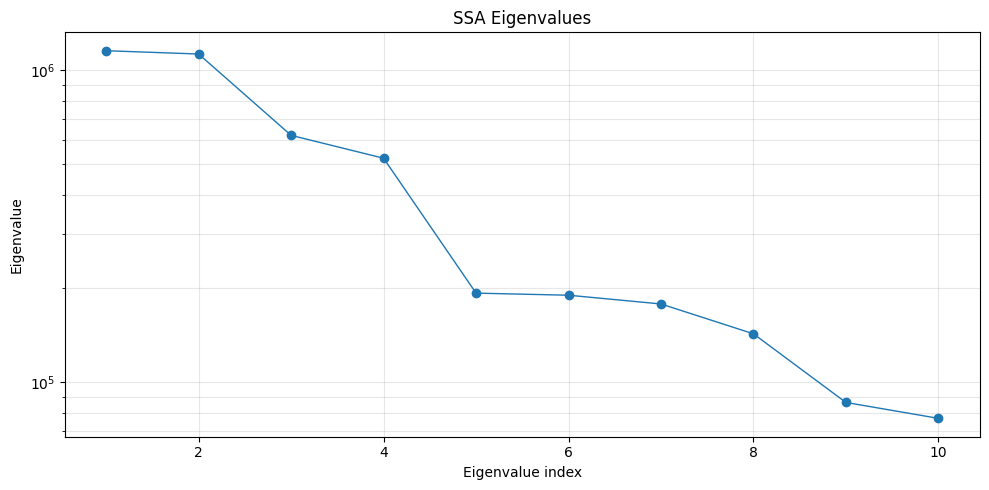

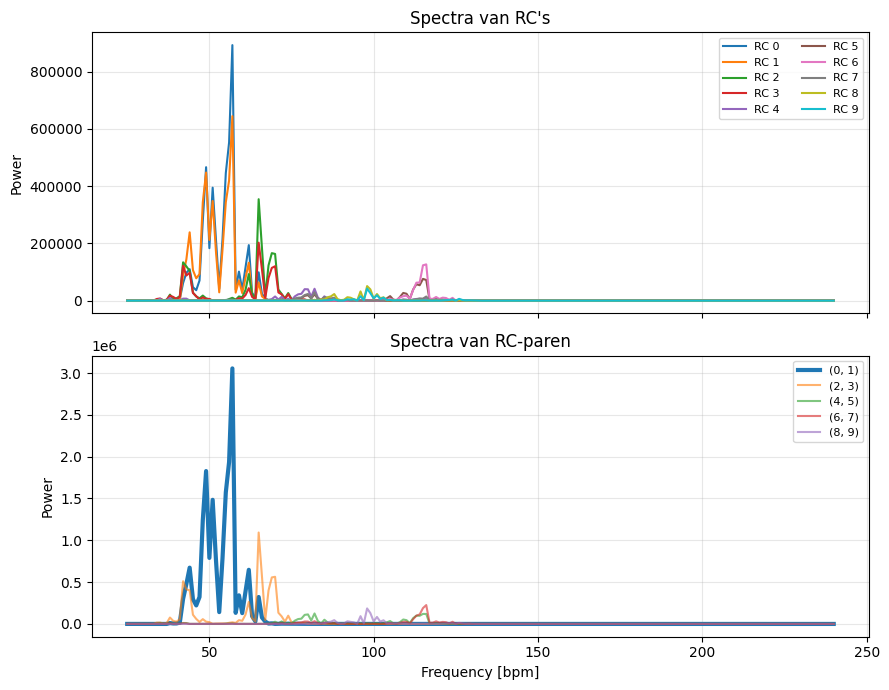

In [5]:
plot_ssa_overview(s, RCs, rc_pairs, pair_scores, fs, chosen_pair, pair_to_highlight=chosen_pair)

## CGO en HR visualisatie

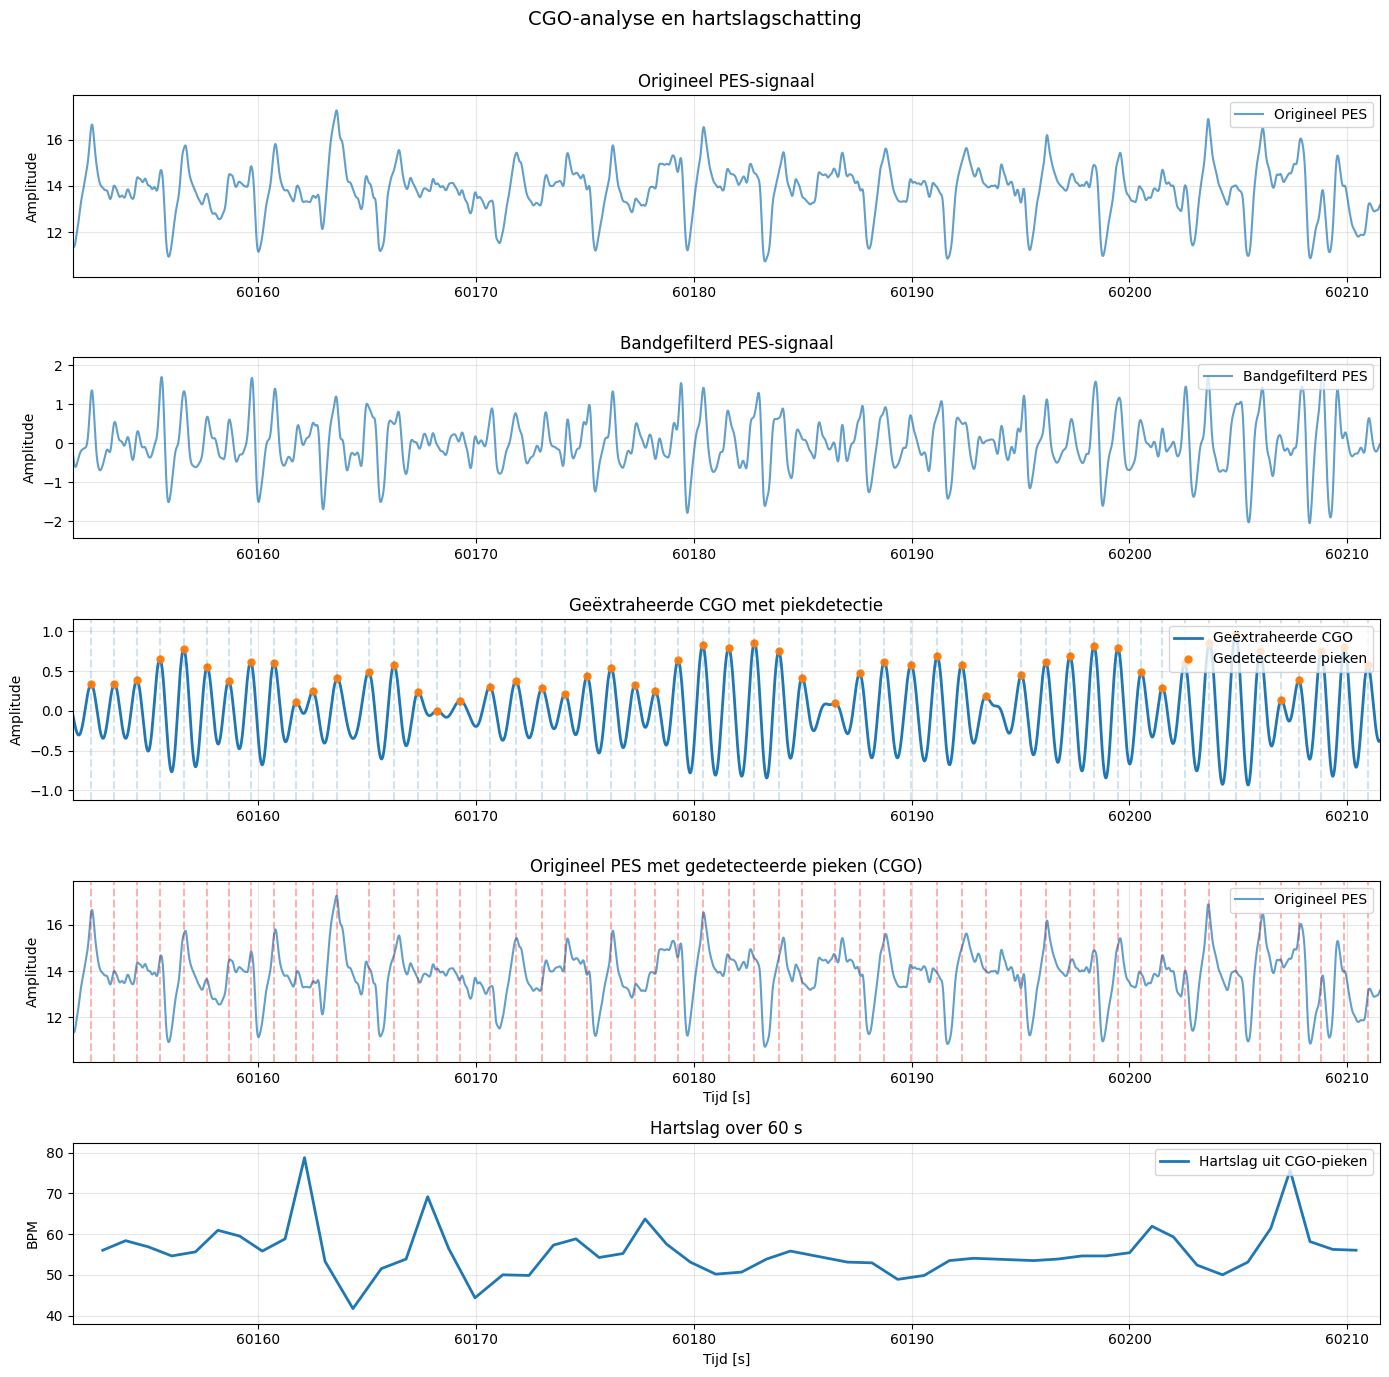

Gemiddelde hartslag uit pieken: 55.80 bpm
Mediaan hartslag uit pieken:    54.66 bpm


In [5]:
plot_cgo_analysis(
    time_window,
    pes_window,
    pes_bp,
    cgo,
    peaks,
    t_hr,
    hr,
)